Pipeline template

Notebook to illustrate the overall pipeline flow including:

- reading in data
- adding non signal noise
- modifying record to be input ready
- inputting to DMD
- converting recovered outputs to comparable outputs
- examining recovery metrics

## Preamble

In [50]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing

# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application


## Reading in data

In [52]:
# Defining test parameters

# defining modes used
mode_numbers = np.arange(1, 62, 1)
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# defining spherical harmonic degree cutoff
nmax = 6

hankel=False
embedding_d=6

dmd_type_used = 'exact'

bopdmd=True
bopdmd_params = {
    "num_trials":50,
    "trial_size":0.6,
    "remove_bad_bags":True,
}

fbdmd = False

svd_rank = -1

In [53]:
# LOADING IN DATA

# CHAOS gauss coeffs
gnm_chaos = CHAOS_Full_SV_Record_Obtain(nmax=nmax)

# Synthetic gauss coeffs
gnm_syn_ideal, gnm_syn, syn_suite_info = Synthetic_Full_SV_Record_Obtain(mode_numbers, times_used_relative, nmax=nmax)

# PREPARING DATA

# applying just to ideal synthetic record - equivalent to others
gnm_syn_non_wave = Non_Wave_Spectral_Infill(gnm_chaos, gnm_syn, dt_sample=dt_sample)


# [input ensemble generation + non wave signal addition here]

gnm_syn_infilled = gnm_syn_non_wave

# PROJECTING DATA TO PHYSICAL SV GRID

A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=nmax)


Full CHAOS-8.6 timespan is: [1997.1 2026.6]


## inputting to DMD to recover interpretable modes

In [54]:
def Run_DMD(X, times_used, dmd_type_used, svd_rank, hankel, embedding_d, fbdmd):

    if dmd_type_used == "exact":
        dmd_base = Build_Exact_DMD(svd_rank, fbdmd=fbdmd)
    elif dmd_type_used == "opdmd":
        dmd_base = Build_BOPDMD(svd_rank, bopdmd=bopdmd, bopdmd_params=bopdmd_params)


    if hankel:
        dmd = hankel_preprocessing(dmd_base, d=embedding_d, reconstruction_method="first")
        times_fit = times_used[: -(embedding_d-1)]
    else:
        dmd = dmd_base
        times_fit = times_used

    if dmd_type_used == 'exact':
        dmd.fit(X)

    elif dmd_type_used == 'opdmd':
        dmd.fit(X, times_fit)

    recovered_modes = DMD_Mode_Process(dmd, dmd_type_used, dt_sample, hankel, embedding_d)

    return(recovered_modes)

## Comparing recovery success


In [55]:
def Match_Input_Output_Modes(syn_suite_info, recovered_modes):
    # have set of input and ouput phasors + periods

    period_threshold = 0.5
    similarity_threshold = 0

    # match all inputs to an output

    output_periods = recovered_modes["periods"]
    output_phasors = recovered_modes["phasors"]

    match_results = {}

    for mode_key in syn_suite_info:

        input_gnm_phasor = syn_suite_info[mode_key]["gnm_phasor"]

        input_phasor = A_r @ input_gnm_phasor.T

        input_period = syn_suite_info[mode_key]["true_period"]

        match_made = False

        best_similarity = 0

        for output_idx, output_period in enumerate(output_periods):

            period_error = np.abs((output_period - input_period)/(input_period))

            if period_error < period_threshold:

                output_phasor = output_phasors[output_idx]

                similarity = Complex_Phasor_Compare(input_phasor, output_phasor)

                if similarity >= similarity_threshold and similarity > best_similarity:

                    match_made = True
                    match_period_error = period_error
                    match_similarity = similarity
                    best_similarity = similarity

        if match_made:
            match_results[mode_key] = {
                "period_error":match_period_error, 
                "similarity":match_similarity
            }
        else:
            match_results[mode_key] = None

    return(match_results)



In [56]:
# now looping through pipeline
# want: 1 ideal test, 1 resolved test, 1 background test, 100 noise ensembles.

results_dict = {}

record_dict = {
    "background":gnm_syn_infilled,
}

for record_key in record_dict:

    record_used = record_dict[record_key]

    # projecting to physical space
    record_physical = A_r @ record_used.T

    print(f"record {record_key} complete!")

    # running DMD
    recovered_modes = Run_DMD(record_physical, times_used_relative, dmd_type_used, svd_rank, hankel, embedding_d, fbdmd)

    # matching input and output modes
    match_results = Match_Input_Output_Modes(syn_suite_info, recovered_modes)

    results_dict[record_key] = match_results

# running perturbation ensembles

n_ensembles = 100


perturbation_path = (
    Path(CHAOS_COV_DIR)
    / (
        "CHAOS_0806_nmax15_SV_nTyr_perturbations_N1000_Nt53.h5"
    )
)

ensemble_results = {}

for mode_key in syn_suite_info:
    ensemble_results[mode_key] = {
        "period_error":[],
        "similarity":[],
        "no_match_count":0,
    }

with h5py.File(perturbation_path, "r") as f:

    for i in tqdm(range(n_ensembles), desc="ensembles"):

        gnm_perturbation_i = f["perturbations"][i, :, :].T

        # truncating to nmax
        gnm_perturbation_i = Truncate_Gauss_Coeffs(gnm_perturbation_i, tmax=nmax)
        gnm_perturbed_i = gnm_syn_infilled + gnm_perturbation_i

        # projecting to physical space
        record_physical = A_r @ gnm_perturbed_i.T

        # running DMD
        recovered_modes = Run_DMD(record_physical, times_used_relative, dmd_type_used, svd_rank, hankel, embedding_d, fbdmd)

        # matching input and output modes
        match_results = Match_Input_Output_Modes(syn_suite_info, recovered_modes)

        for mode_key in match_results:
            if match_results[mode_key]:
                ensemble_results[mode_key]["period_error"].append(match_results[mode_key]["period_error"])
                ensemble_results[mode_key]["similarity"].append(match_results[mode_key]["similarity"])
            else:
                ensemble_results[mode_key]["no_match_count"] += 1

results_dict["ensemble"] = ensemble_results


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.4031274320261668e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


record background complete!


ensembles:   0%|          | 0/100 [00:00<?, ?it/s]/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.573312267576691e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
ensembles:   1%|          | 1/100 [00:00<00:16,  5.97it/s]/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.459324713220248e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.7150663585879396e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
ensembles:   3%|▎         | 3/100 [00:00<00:21,  4.53it/s]/home/elliott/miniforge3/envs/msc_thesis/

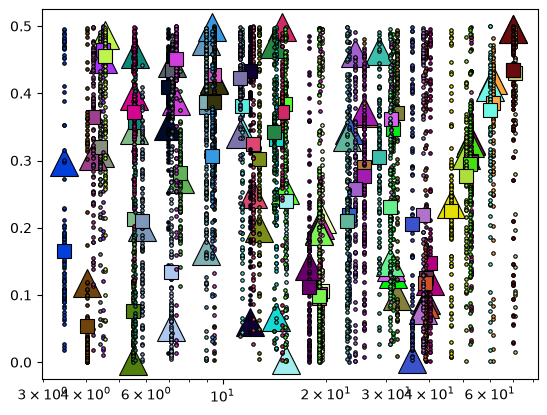

In [57]:
# looking at each record outcomes
plot_rules = {
    "ideal":{
        "shape":"o",
        "size":10,
    },
    "resolved":{
        "shape":"X",
        "size":10,
    },
    "background":{
        "shape":"^",
        "size":20,
    },
    "ensemble":{
        "shape":".",
        "size":5,
    }
}

mode_colours = {}
rng = np.random.default_rng(5)

for mode_key in mode_numbers:

    random_colour = rng.random(3)
    mode_colours[mode_key] = random_colour




for result_type in results_dict:

    result_info = results_dict[result_type]

    for mode_key in mode_numbers:

        mode_info = syn_suite_info[mode_key]
        period = mode_info["true_period"]
        mode_result = result_info[mode_key]

        if mode_result:

            if result_type == "ensemble":

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]
                num_unmatched = mode_result["no_match_count"]

                period_plot = period * np.ones_like(period_error)

            else:

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]

                period_plot = period

            plot_rule = plot_rules[result_type]

            plt.semilogx(period_plot, 
                        period_error, 
                        color=mode_colours[mode_key], 
                        marker=plot_rule["shape"], 
                        ms=plot_rule["size"], 
                        markeredgecolor="black",
                        markeredgewidth=0.8,
                        linestyle=' ')

            if result_type == "ensemble":
                plt.semilogx(period, 
                            np.median(period_error), 
                            color=mode_colours[mode_key], 
                            marker="s", 
                            ms=10, 
                            markeredgecolor="black",
                            markeredgewidth=0.8,
                            linestyle=' ')




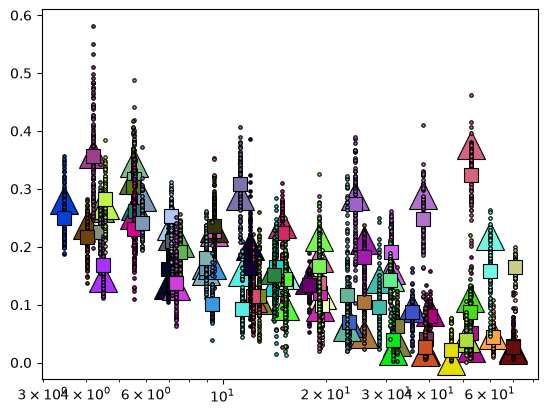

In [58]:

for result_type in results_dict:

    result_info = results_dict[result_type]

    for mode_key in mode_numbers:

        mode_info = syn_suite_info[mode_key]
        period = mode_info["true_period"]
        mode_result = result_info[mode_key]

        if mode_result:

            if result_type == "ensemble":

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]
                num_unmatched = mode_result["no_match_count"]

                period_plot = period * np.ones_like(period_error)

            else:

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]

                period_plot = period

            plot_rule = plot_rules[result_type]

            plt.semilogx(period_plot, 
                        similarity, 
                        color=mode_colours[mode_key], 
                        marker=plot_rule["shape"], 
                        ms=plot_rule["size"], 
                        markeredgecolor="black",
                        markeredgewidth=0.8,
                        linestyle=' ')

            if result_type == "ensemble":
                plt.semilogx(period, 
                            np.median(similarity), 
                            color=mode_colours[mode_key], 
                            marker="s", 
                            ms=10, 
                            markeredgecolor="black",
                            markeredgewidth=0.8,
                            linestyle=' ')